# Getting started with TinyTimeMixer (TTM)

This notebooke demonstrates the usage of a pre-trained `TinyTimeMixer` model for several multivariate time series forecasting tasks. For details related to model architecture, refer to the [TTM paper](https://arxiv.org/pdf/2401.03955.pdf).

## Installation

In [1]:
# Install the tsfm library
! pip install "tsfm_public[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.18"

  Cloning https://github.com/ibm-granite/granite-tsfm.git (to revision v0.2.18) to c:\users\srina\appdata\local\temp\pip-install-ycum6v01\tsfm-public_b9bdb1c3d3264ea48bf936a647a523db


  Running command git clone --filter=blob:none --quiet https://github.com/ibm-granite/granite-tsfm.git 'C:\Users\srina\AppData\Local\Temp\pip-install-ycum6v01\tsfm-public_b9bdb1c3d3264ea48bf936a647a523db'
  error: unable to create file notebooks/hfdemo/adaptive_conformal_tsad/output/672_YAHOO_id_122_WebService_tr_500_1st_857/chronos-bolt-small_90_15/W1ACAS_absolute_error_Cauchy/anomaly_detection_visualization.png: Filename too long
  error: unable to create file notebooks/hfdemo/adaptive_conformal_tsad/output/672_YAHOO_id_122_WebService_tr_500_1st_857/chronos-bolt-small_90_15/W1ACAS_absolute_error_Cauchy/evaluation.json: Filename too long
  error: unable to create file notebooks/hfdemo/adaptive_conformal_tsad/output/672_YAHOO_id_122_WebService_tr_500_1st_857/chronos-bolt-small_90_15/W1ACAS_absolute_error_Cauchy/evaluation_tsb_ad.json: Filename too long
  error: unable to create file notebooks/hfdemo/adaptive_conformal_tsad/output/672_YAHOO_id_122_WebService_tr_500_1st_857/chronos-bolt-

## Imports

In [2]:
import math
import os
import tempfile

import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed

from tsfm_public import (
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
    TrackingCallback,
    count_parameters,
    get_datasets,
)
from tsfm_public.toolkit.visualization import plot_predictions

## Important arguments

In [3]:
# Set seed for reproducibility
SEED = 42
set_seed(SEED)

# DATA ROOT PATH
# Make sure to download the target data (here ettm2) on the `DATA_ROOT_PATH` folder.
# ETT is available at: https://github.com/zhouhaoyi/ETDataset/tree/main
target_dataset = "ettm2"
DATA_ROOT_PATH = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv"

# Results dir
OUT_DIR = "ttm_finetuned_models/"

# Forecasting parameters
context_length = 168
forecast_length = 24
fewshot_fraction = 0.05

# ----- TTM model path -----
TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
# TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"

# ----- TTM model branch -----
# For R2 models
TTM_MODEL_REVISION = "main"
# TTM_MODEL_REVISION="1024-96-r2"
# TTM_MODEL_REVISION="1536-96-r2"

# For R1 models
# TTM_MODEL_REVISION = "main"
# TTM_MODEL_REVISION="1024_96_v1"

## Data processing pipeline

**Note:** Here we demonstrate how to use the TimeSeriesPreprocessor (TSP) module for data preparation. A step-by-step usage is shown below. For standard datasets, TSP can quickly prepare the dataloaders using YAML files defined [here](https://github.com/ibm-granite/granite-tsfm/tree/main/tsfm_public/resources/data_config). Refer to the [TTM Getting Started](https://github.com/ibm-granite/granite-tsfm/blob/main/notebooks/hfdemo/ttm_getting_started.ipynb) for example usage. Similar YAML file can be written for any new dataset as well.


In [4]:
# Load the data file and see the columns
df_tmp = pd.read_csv(DATA_ROOT_PATH)
df_tmp

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999
1,2016-07-01 00:15:00,39.622002,11.309,35.543999,8.551,3.209,1.258,38.223000
2,2016-07-01 00:30:00,38.868000,10.555,34.365002,7.586,4.435,1.258,37.344002
3,2016-07-01 00:45:00,35.518002,9.214,32.569000,8.712,4.435,1.215,37.124001
4,2016-07-01 01:00:00,37.528000,10.136,33.936001,7.532,4.435,1.215,37.124001
...,...,...,...,...,...,...,...,...
69675,2018-06-26 18:45:00,42.722000,12.230,54.014000,12.652,-11.525,-1.418,45.986500
69676,2018-06-26 19:00:00,38.868000,10.052,49.859001,10.669,-11.525,-1.418,45.986500
69677,2018-06-26 19:15:00,39.622002,11.057,50.448002,11.795,-10.299,-1.418,45.546501
69678,2018-06-26 19:30:00,40.459999,11.392,51.841999,11.929,-11.536,-1.418,45.546501


<Axes: xlabel='date'>

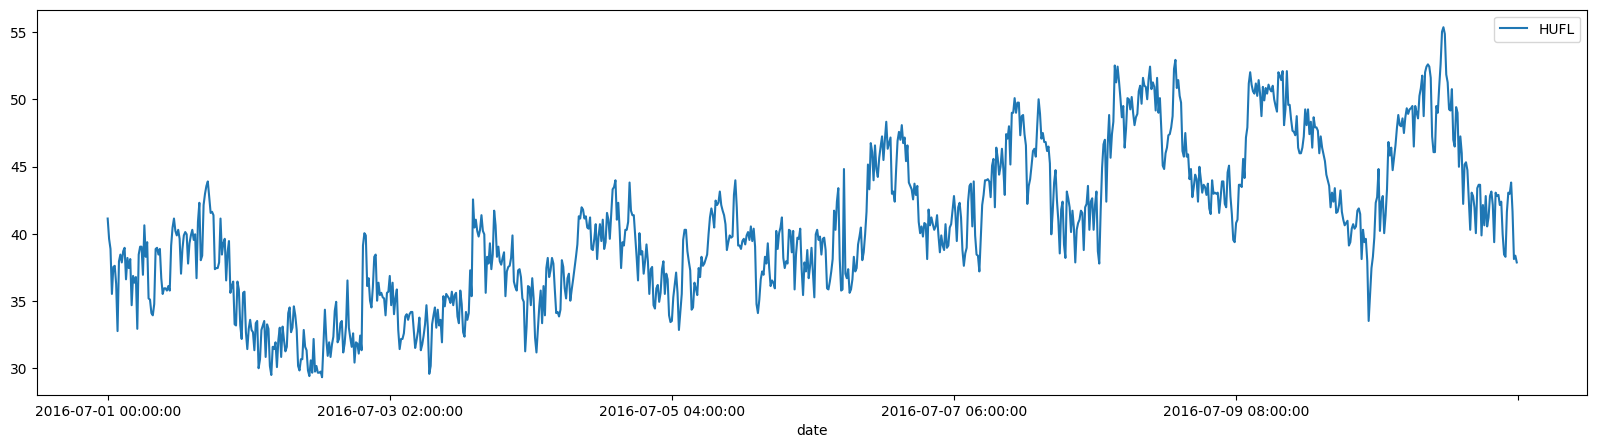

In [5]:
df_tmp.iloc[:1000].plot(x="date", y="HUFL", figsize=(20, 5))

In [6]:
dataset_path = DATA_ROOT_PATH
timestamp_column = "date"
id_columns = []
target_columns = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
split_config = {
    "train": [0, 12 * 30 * 24 * 4],
    "valid": [12 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4],
    "test": [
        12 * 30 * 24 * 4 + 4 * 30 * 24 * 4,
        12 * 30 * 24 * 4 + 8 * 30 * 24 * 4,
    ],
}
# Understanding the split config -- slides


In [7]:

data = pd.read_csv(
    dataset_path,
    parse_dates=[timestamp_column],
)

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
}

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=forecast_length,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
)

train_dataset, valid_dataset, test_dataset = get_datasets(
    tsp, data, split_config, fewshot_fraction=fewshot_fraction, fewshot_location="first"
)
print(f"Data lengths: train = {len(train_dataset)}, val = {len(valid_dataset)}, test = {len(test_dataset)}")

Data lengths: train = 1696, val = 11497, test = 11497


In [9]:
train_dataset[3].keys()

dict_keys(['past_values', 'future_values', 'past_observed_mask', 'future_observed_mask', 'timestamp', 'id'])

In [8]:
train_dataset[3]['future_values'].size()

torch.Size([24, 7])

In [10]:
train_dataset[3]['past_observed_mask'].size()

torch.Size([168, 7])

In [11]:
train_dataset[3]['past_values'].size()

torch.Size([168, 7])

## Zero-shot evaluation method

In [13]:
import json

from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig
from tsfm_public.models.tinytimemixer.modeling_tinytimemixer import TinyTimeMixerForPrediction

with open('config_168.json', 'r') as file:
    cfg = json.load(file)

config = TinyTimeMixerConfig(**cfg)

model = TinyTimeMixerForPrediction.from_pretrained(
    TTM_MODEL_PATH,
    config=config,
    ignore_mismatched_sizes=True
)

Some weights of TinyTimeMixerForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 and are newly initialized: ['backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.gating_block.attn_layer.bias', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.gating_block.attn_layer.weight', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.mlp.fc1.bias', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.mlp.fc1.weight', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.mlp.fc2.bias', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.mlp.fc2.weight', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.norm.norm.bias', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.norm.norm.weight', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.patch_mixer.gating_block.

In [14]:
# zeroshot_model = TinyTimeMixerForPrediction.from_pretrained(TTM_MODEL_PATH, revision=TTM_MODEL_REVISION,config=)
# zeroshot_model

In [15]:
temp_dir = tempfile.mkdtemp()
# zeroshot_trainer
model_trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=64,
        seed=SEED,
    ),
)

In [16]:
model_trainer.evaluate(test_dataset)

c:\Users\srina\anaconda3\envs\tspulse_env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.22141821682453156,
 'eval_model_preparation_time': 0.003,
 'eval_runtime': 6.6695,
 'eval_samples_per_second': 1723.816,
 'eval_steps_per_second': 26.989}

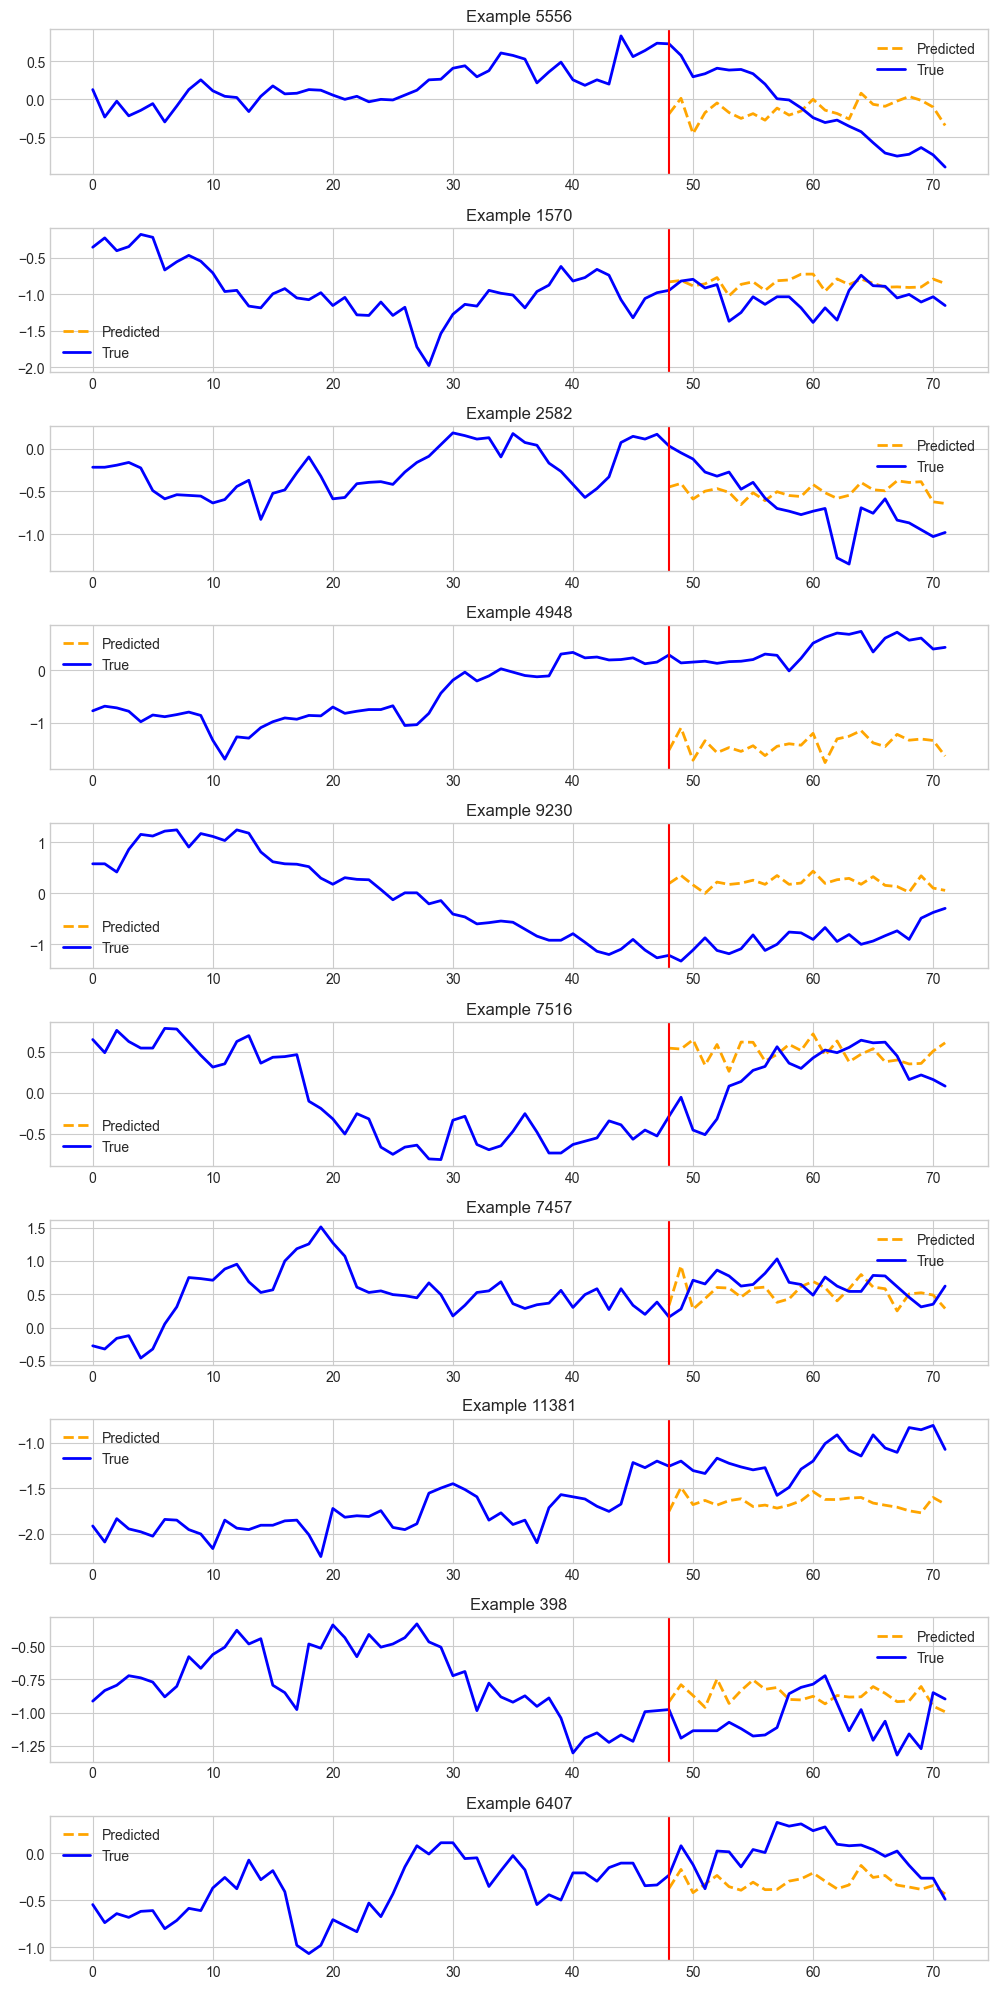

In [17]:
# plot
plot_predictions(
    model=model_trainer.model,
    dset=test_dataset,
    plot_dir=os.path.join(OUT_DIR, "ettm2"),
    plot_prefix="test_zeroshot",
    channel=0,
)

 ## Few-shot finetune and evaluation method

### Load model
Optionally, we can change some parameters of the model, e.g., dropout of the head.

In [19]:
with open('config_168.json', 'r') as file:
    cfg = json.load(file)

config = TinyTimeMixerConfig(**cfg)

finetune_forecast_model = TinyTimeMixerForPrediction.from_pretrained(
    TTM_MODEL_PATH,
    config=config,
    ignore_mismatched_sizes=True,
    # head_dropout=0.7
)

finetune_forecast_model

Some weights of TinyTimeMixerForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 and are newly initialized: ['backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.gating_block.attn_layer.bias', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.gating_block.attn_layer.weight', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.mlp.fc1.bias', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.mlp.fc1.weight', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.mlp.fc2.bias', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.mlp.fc2.weight', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.norm.norm.bias', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.feature_mixer.norm.norm.weight', 'backbone.encoder.mlp_mixer_encoder.mixers.0.mixer_layers.2.patch_mixer.gating_block.

TinyTimeMixerForPrediction(
  (backbone): TinyTimeMixerModel(
    (encoder): TinyTimeMixerEncoder(
      (patcher): Linear(in_features=24, out_features=16, bias=True)
      (mlp_mixer_encoder): TinyTimeMixerBlock(
        (mixers): ModuleList(
          (0): TinyTimeMixerAdaptivePatchingBlock(
            (mixer_layers): ModuleList(
              (0-2): 3 x TinyTimeMixerLayer(
                (patch_mixer): PatchMixerBlock(
                  (norm): TinyTimeMixerNormLayer(
                    (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
                  )
                  (mlp): TinyTimeMixerMLP(
                    (fc1): Linear(in_features=7, out_features=21, bias=True)
                    (dropout1): Dropout(p=0.3, inplace=False)
                    (fc2): Linear(in_features=21, out_features=7, bias=True)
                    (dropout2): Dropout(p=0.3, inplace=False)
                  )
                  (gating_block): TinyTimeMixerGatedAttention(
                 

### Frezze the TTM backbone

In [20]:
print(
    "Number of params before freezing backbone",
    count_parameters(finetune_forecast_model),
)

# Freeze the backbone of the model
for param in finetune_forecast_model.backbone.parameters():
    param.requires_grad = False

# Count params
print(
    "Number of params after freezing the backbone",
    count_parameters(finetune_forecast_model),
)

Number of params before freezing backbone 28858
Number of params after freezing the backbone 8688


### Finetune few-shot 5%

In [24]:
# Important parameters
learning_rate = 0.001
num_epochs = 10  # Ideally, we need more epochs (try offline preferably in a gpu for faster computation)
batch_size = 64

In [25]:
print(f"Using learning rate = {learning_rate}")
finetune_forecast_args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "output"),
    overwrite_output_dir=True,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=8,
    report_to=None,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    logging_dir=os.path.join(OUT_DIR, "logs"),  # Make sure to specify a logging directory
    load_best_model_at_end=True,  # Load the best model when training ends
    metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
    greater_is_better=False,  # For loss
    seed=SEED,
)

# Create the early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
    early_stopping_threshold=0.0,  # Minimum improvement required to consider as improvement
)
tracking_callback = TrackingCallback()

# Optimizer and scheduler
optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
scheduler = OneCycleLR(
    optimizer,
    learning_rate,
    epochs=num_epochs,
    steps_per_epoch=math.ceil(len(train_dataset) / (batch_size)),
)

finetune_forecast_trainer = Trainer(
    model=finetune_forecast_model,
    args=finetune_forecast_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[early_stopping_callback, tracking_callback],
    optimizers=(optimizer, scheduler),
)

# Fine tune
finetune_forecast_trainer.train()

Using learning rate = 0.001


c:\Users\srina\anaconda3\envs\tspulse_env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,0.168500,0.150306
2,0.163900,0.141242
3,0.145100,0.116734
4,0.119900,0.101383
5,0.108000,0.097887
6,0.103600,0.096977
7,0.101400,0.095777
8,0.099400,0.095528
9,0.098900,0.095533
10,0.099200,0.095469


c:\Users\srina\anaconda3\envs\tspulse_env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\srina\anaconda3\envs\tspulse_env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\srina\anaconda3\envs\tspulse_env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\srina\anaconda3\envs\tspulse_env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\srina\anaconda3\envs\ts

[TrackingCallback] Mean Epoch Time = 88.78373618125916 seconds, Total Train Time = 1712.7516770362854


TrainOutput(global_step=270, training_loss=0.12079304677468759, metrics={'train_runtime': 1712.7418, 'train_samples_per_second': 9.902, 'train_steps_per_second': 0.158, 'total_flos': 3453429934080.0, 'train_loss': 0.12079304677468759, 'epoch': 10.0})

In [26]:
finetune_forecast_trainer.evaluate(test_dataset)

c:\Users\srina\anaconda3\envs\tspulse_env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.12273004651069641,
 'eval_runtime': 132.1177,
 'eval_samples_per_second': 87.021,
 'eval_steps_per_second': 1.362,
 'epoch': 10.0}

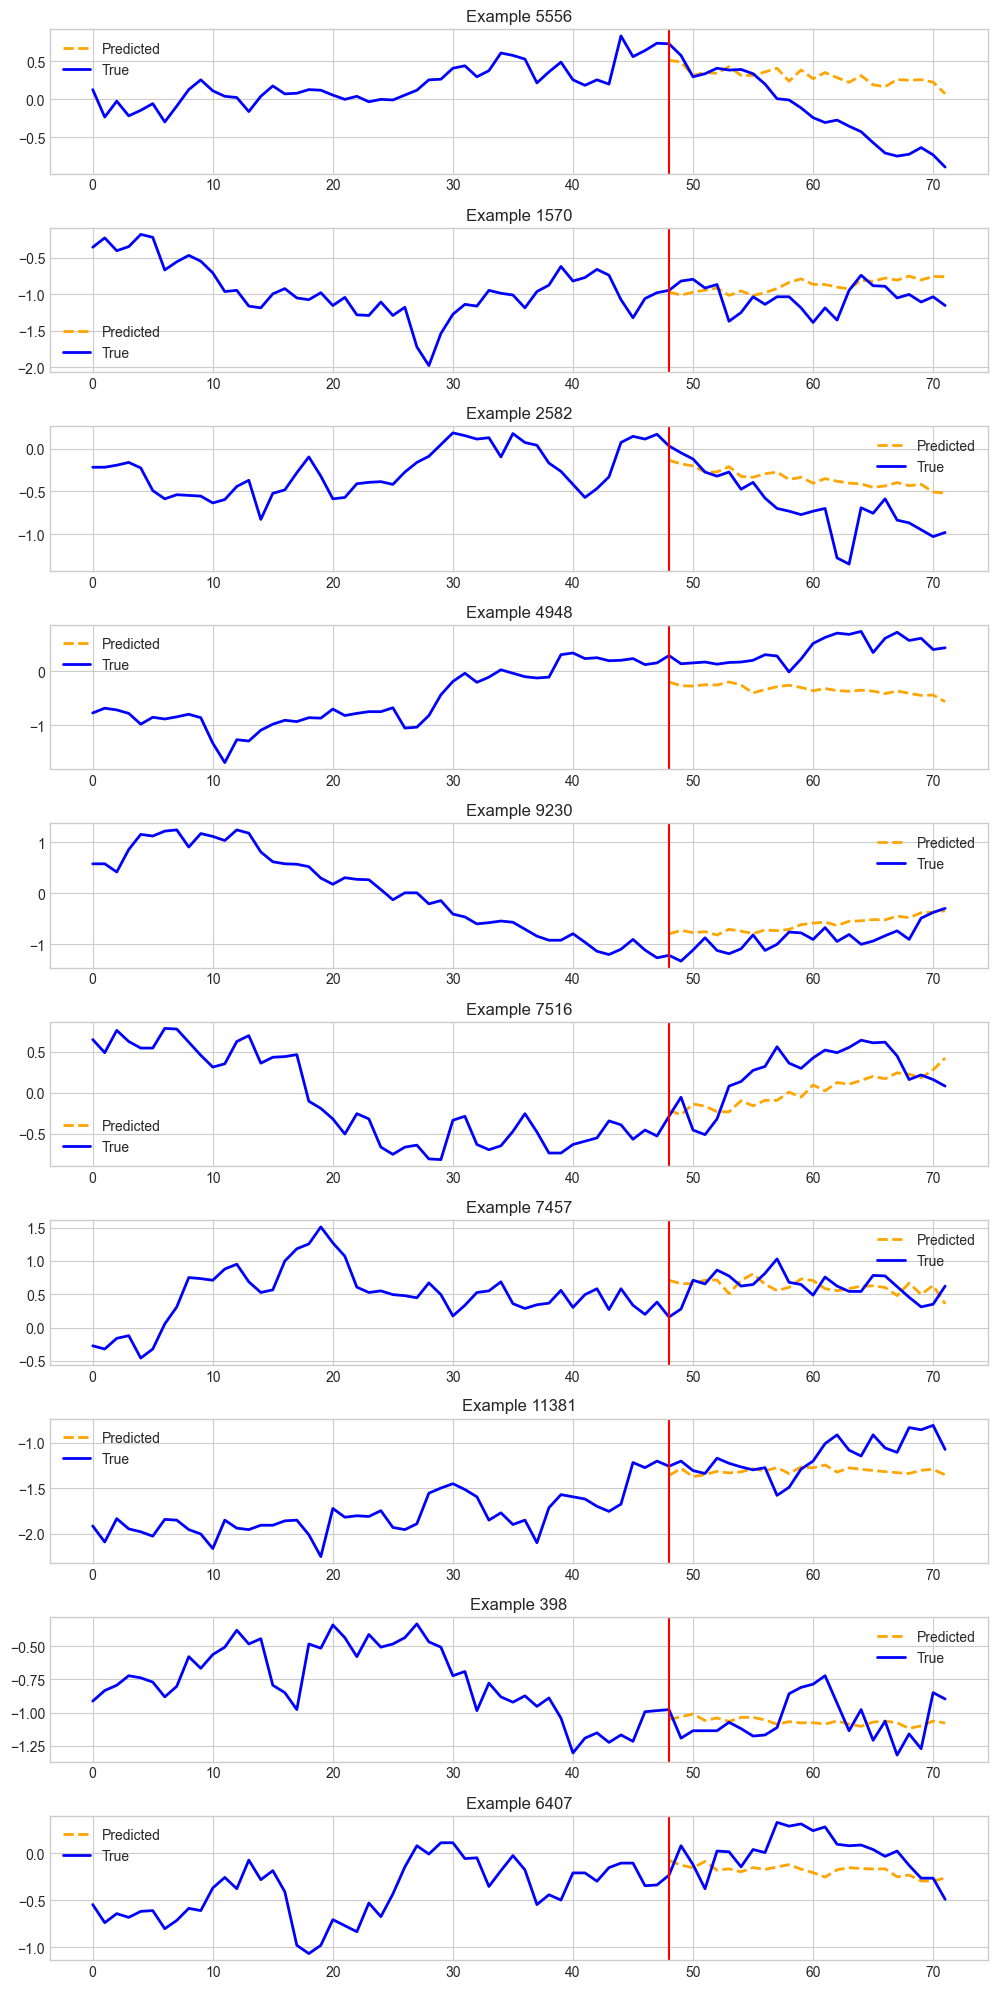

In [27]:
# plot
plot_predictions(
    model=finetune_forecast_trainer.model,
    dset=test_dataset,
    plot_dir=os.path.join(OUT_DIR, "ettm2"),
    plot_prefix="test_zeroshot",
    channel=0,
)